In [1]:
from dataclasses import dataclass, field, InitVar
from math import tau, cos, sin
import numpy as np
import hashlib
from collections.abc import Iterable, Generator, Iterator
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator

In [2]:
def to_decibel(p: np.ndarray, p_0: np.ndarray) -> np.ndarray:
    return 10.0 * np.log10((p + 1e-10) / (p_0 + 1e-10))


def _filter_pass(state: tuple[float, float], sample: float, omega: complex) -> tuple[float, float]:
    d1, d2 = state
    y = sample + omega.real * d1 - d2
    return y, d1


def _power(state: tuple[float, float], omega: complex) -> float:
    d1, d2 = state
    return pow(d1, 2) + pow(d2, 2) - omega.real * d1 * d2


@dataclass(slots=True, frozen=True)
class State:
    """
    Represents a copy of the Goertzel filter state at a specific point in time `n`.
    """
    
    omega: complex
    state: tuple[float, float]

    @property
    def d1(self) -> float:
        """
        Return the value of the intermediate sequence at time `n`.
        """
        return self.state[0]

    @property
    def d2(self) -> float:
        """
        Return the value of the intermediate sequence at time `n - 1`.
        """
        return self.state[1]

    def power(self) -> float:
        """
        Return the spectral power (absolute value, linear scale)
        """
        return _power(self.state, self.omega)


@dataclass(slots=True)
class Goertzel:
    """
    Implements the Goertzel algorithm for an unknown number of samples. This is to be used when streaming data.
    """
    
    sample_rate: InitVar[int]
    frequency: InitVar[int]
    omega: complex = field(init=False)
    state: tuple[float, float] = field(init=False, default=(0.0, 0.0))

    def __post_init__(self, sample_rate: int, frequency: int) -> None:
        phi = tau * frequency / sample_rate
        self.omega = complex(2 * cos(phi), sin(phi))

    def reset(self) -> None:
        """
        Reset the state of the filter and thus discard all previously integrated data.
        """
        self.state = (0.0, 0.0)

    def add_sample(self, sample: float) -> State:
        """
        Add a single sample of a discrete waveform and return a frozen copy of the current filter state.
        """
        self.state = _filter_pass(self.state, sample, self.omega)
        return State(self.omega, self.state)


@dataclass(slots=True)
class Oscillator:
    """
    Represents a circular iterator over the range 0:period_length. This iterator is infinite.
    """
    
    period_length: int
    counter: int = field(init=False, default=0)

    def reset(self) -> None:
        """
        Reset the current iteration count to zero.
        """
        self.counter = 0

    def __iter__(self) -> 'Oscillator':
        return self

    def __next__(self) -> int:
        self.counter = (self.counter + 1) % self.period_length
        return self.counter


@dataclass
class TwoToneGoertzel:
    """
    Given a 2-FSK encoded source signal, apply to it two separate Goertzel filters, and return their states at specific time points.
    This class implements the Iterable interface, so it works even for unbounded signals.
    An internal oscillator represents the bit clock which resets the Goertzel filters periodically to allow bit signal retrieval.
    """
    
    source: InitVar[Iterable[float]]
    sample_rate: InitVar[int]
    mark_frequency: InitVar[int]
    space_frequency: InitVar[int]
    bit_width: InitVar[int]
    edge_threshold: float = field(default=0.5)
    edge_state: bool = field(init=False, default=False)
    mark: Goertzel = field(init=False)
    space: Goertzel = field(init=False)
    nco: Oscillator = field(init=False)
    source_iter: Iterator[tuple[int, float]] = field(init=False)

    def __post_init__(self, source: Iterable[float], sample_rate: int, mark_frequency: int, space_frequency: int, bit_width: int) -> None:
        self.mark = Goertzel(sample_rate, mark_frequency)
        self.space = Goertzel(sample_rate, space_frequency)
        self.nco = Oscillator(bit_width)
        self.source_iter = enumerate(iter(source))

    def __iter__(self) -> 'TwoToneGoertzel':
        return self

    def __next__(self) -> tuple[State, State]:
        idx, sample = next(self.source_iter)
        
        # Get current clock position BEFORE processing
        if self.edge_state:
            clock = self.nco.counter
            
            # Reset at START of new bit period
            if clock == 0:
                self.mark.reset()
                self.space.reset()
        
        # Now process the sample
        mark_state = self.mark.add_sample(sample)
        space_state = self.space.add_sample(sample)
        power_delta = mark_state.power() - space_state.power()
    
        # Sync on first rising edge
        if not self.edge_state and power_delta > self.edge_threshold:
            print(f'[{idx=}] Rising edge reset: {self.nco.counter=}')
            self.edge_state = True
            self.nco.reset()
        
        # Increment clock for next sample
        if self.edge_state:
            next(self.nco)
    
        return (mark_state, space_state)       

In [3]:
with open('modulated-normalized-six-bits.npz', mode='rb') as f:
    digest = hashlib.file_digest(f, "sha256")
    assert digest.hexdigest() == "6e26e3d25dcfd5b5856dbd33ca745258842eaca7ee6bb578d52c60f18802cec1"
    f.seek(0)
    with np.load(f, allow_pickle=False) as data:
        source = data['source']
        modulated = data['modulated']

print(f"{source.shape=}, {source.dtype=}")
print(f"{modulated.shape=}, {modulated.dtype=}")

source.shape=(6,), source.dtype=dtype('bool')
modulated.shape=(192,), modulated.dtype=dtype('float64')


In [4]:
# Introduce zeros at the beginning and end, then add noise
np.random.seed(0)
def apply_noise(signal: np.ndarray, padding: int) -> np.ndarray:
    s = np.concat([np.zeros((padding,)), signal, np.zeros((padding,))])
    n = 0.1 * np.random.randn(s.shape[0])
    return s + n

padding = 0
noisy = apply_noise(modulated, padding)

In [5]:
states = np.array([[mark.d1, mark.d2, mark.power(), space.d1, space.d2, space.power()] for mark, space in TwoToneGoertzel(noisy, 9600, 2400, 1200, 32)])

[idx=2] Rising edge reset: self.nco.counter=0


Text(0.5, 1.0, 'Spectral Power Ratio (dB)')

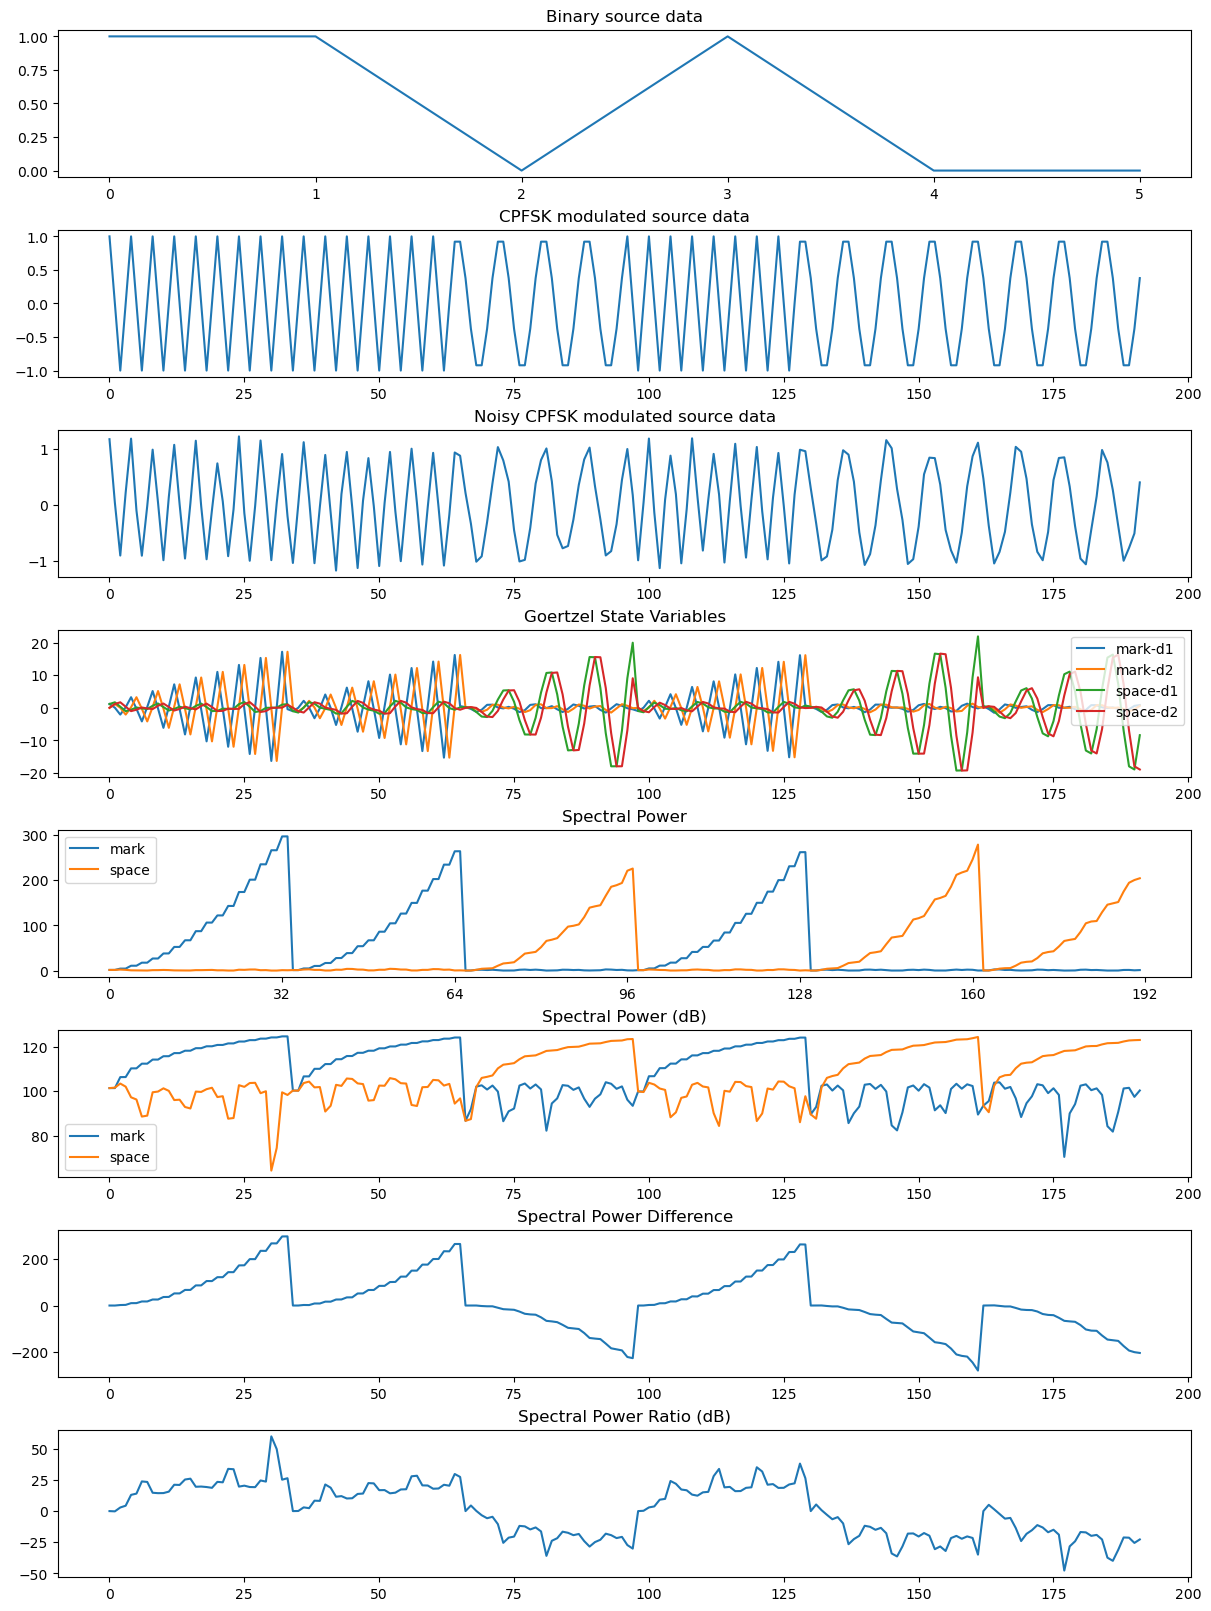

In [6]:
fig = plt.figure(figsize=(12, 16), dpi=100, layout='constrained')
axs = fig.subplot_mosaic([
    ['source'], 
    ['modulated'],
    ['noisy'],
    ['state'],
    ['power'],
    ['power_db'],
    ['power_diff'],
    ['power_ratio'],
])
axs['source'].plot(source)
axs['source'].set_title('Binary source data')
axs['modulated'].plot(modulated)
axs['modulated'].set_title('CPFSK modulated source data')
axs['noisy'].plot(noisy)
axs['noisy'].set_title('Noisy CPFSK modulated source data')
axs['state'].plot(states[:, 0], label='mark-d1')
axs['state'].plot(states[:, 1], label='mark-d2')
axs['state'].plot(states[:, 3], label='space-d1')
axs['state'].plot(states[:, 4], label='space-d2')
axs['state'].legend()
axs['state'].set_title('Goertzel State Variables')
axs['power'].plot(states[:, 2], label='mark')
axs['power'].plot(states[:, 5], label='space')
axs['power'].xaxis.set_major_locator(MultipleLocator(32, offset=padding))
axs['power'].legend()
axs['power'].set_title('Spectral Power')
axs['power_db'].plot(to_decibel(states[:, 2], 0), label='mark')
axs['power_db'].plot(to_decibel(states[:, 5], 0), label='space')
axs['power_db'].legend()
axs['power_db'].set_title('Spectral Power (dB)')
axs['power_diff'].plot(states[:, 2] - states[:, 5])
axs['power_diff'].set_title('Spectral Power Difference')
axs['power_ratio'].plot(to_decibel(states[:, 2], states[:, 5]))
axs['power_ratio'].set_title('Spectral Power Ratio (dB)')